In [1]:
from stormpy import export_to_drn
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

from verimon.logger import setup_logging

setup_logging()

In [ ]:
from verimon import loaders
from random import randrange
from math import sqrt


mc_sl_u_nxn = "../tests/snake_ladder/mc_u_nxn.pm"

n, ladders, snakes = loaders.random_snl_board(4**2)
# n, ladders, snakes = (25, {17: 19, 9: 15, 8: 15, 6: 10, 14: 21}, {23: 8, 22: 20, 8: 1, 18: 2, 12: 2})
print(n, ladders, snakes)

# Random snakes and ladders
# mc, expr_man = loaders.load_snl_stormpy(mc_sl_u_nxn, n, ladders, snakes)

milton_snakes = {98: 76, 95: 75, 93: 73, 87: 24, 64: 60, 62: 19, 55: 53, 49: 11, 47: 26, 16: 6}
milton_ladders = {1: 38, 4: 14, 9: 31, 28: 64, 40: 42, 36: 44, 51: 67, 71: 91, 80: 100}
mc, expr_man = loaders.load_snl_stormpy(mc_sl_u_nxn, n := 10**2, ladders:=milton_ladders, snakes:=milton_snakes)

16 {5: 6, 3: 8, 4: 7} {6: 5, 10: 4, 8: 7, 13: 1}


In [3]:
from stormvogel.mapping import stormpy_to_stormvogel
from stormvogel.show import show
import stormvogel

stormvogel.communication_server.enable_server = False

mc_sv = stormpy_to_stormvogel(mc)
if mc_sv is None:
    raise Exception("boom")
loaders._add_valuation_to_sv_labels(mc, mc_sv)
show(mc_sv)

Output()

Output()

Output()

Output()

Output()

Output()

Using matplotlib backend: module://matplotlib_inline.backend_inline


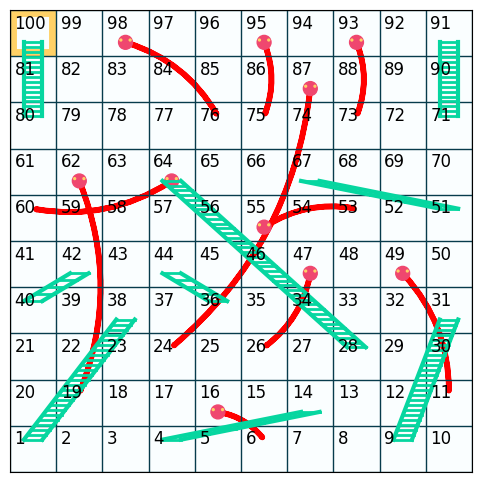

In [4]:
%matplotlib
from verimon.draw import animate_player_movement
import math
from IPython.display import HTML

player_path = [(0, [])]

goal_squares = [next(int(l[5:-1]) for l in state.labels if l.startswith("[pos")) 
                for state in mc_sv.states.values() 
                if "good" in state.labels]

animation = animate_player_movement(int(math.sqrt(n)), snakes, ladders, goal_squares, player_path)
HTML(animation.to_jshtml())

In [ ]:
from aalpy import run_Lstar, Dfa
from verimon.MonitorLearning import FilteringSUL, VerimonEqOracle

setup_logging()


threshold = 0.4
fp_slack = 0.3
fn_slack = 0.05
horizon = 14
relative_error = 0.1
spec = 'P>0.5 [F<3 "good" ]'

alphabet = ["init", "normal", "snake", "ladder"]

filtering_sul = FilteringSUL(
    mc, 
    "init", 
    alphabet, 
    spec, 
    threshold, 
    horizon
)
eq_oracle = VerimonEqOracle(
    alphabet,
    filtering_sul,
    mc,
    threshold,
    fp_slack,
    fn_slack,
    horizon,
    spec,
    'good',
    relative_error,
    expr_man
)
learned_monitor: Dfa = run_Lstar(
    alphabet,
    filtering_sul,
    eq_oracle,
    automaton_type="dfa",
    print_level=2,
) #type: ignore

Hypothesis 1: 1 states.
Visualization started in the background thread.
DEBUG:2024-11-15 15:52:14,035 - (0.00s) - MonitorLearning.py - Finding false negative probability 
DEBUG:2024-11-15 15:52:14,035 - (0.00s) - verify.py - Building model 
Model saved to models/model1.dot.
DEBUG:2024-11-15 15:52:14,036 - (0.00s) - verify.py - Unrolling done 
INFO:2024-11-15 15:52:14,038 - (0.00s) - generator.py - New good states become: [81, 93] 
DEBUG:2024-11-15 15:52:14,038 - (0.00s) - verify.py - Apply spec done 
DEBUG:2024-11-15 15:52:14,096 - (0.06s) - verify.py - creating product done 
DEBUG:2024-11-15 15:52:14,097 - (0.00s) - verify.py - Creating trace 


INFO:paynt.quotient.pomdp:constructed POMDP having 16 observations.


2024-11-15 15:52:14,115 - pomdp.py - constructed POMDP having 16 observations.


DEBUG:paynt.quotient.pomdp:unfolding 1-FSC template into POMDP...


2024-11-15 15:52:14,116 - pomdp.py - unfolding 1-FSC template into POMDP...


...

2024-11-15 16:00:29,056 - pomdp.py - constructed quotient MDP having 3507 states and 17414 actions.
2024-11-15 16:00:29,056 - pomdp.py - constructed quotient MDP having 3507 states and 17414 actions.


INFO:paynt.synthesizer.statistic:synthesis initiated, design space: 1e12


2024-11-15 16:00:29,062 - statistic.py - synthesis initiated, design space: 1e12
2024-11-15 16:00:29,062 - statistic.py - synthesis initiated, design space: 1e12


DEBUG:paynt.family.smt:using Python Z3 for SMT solving.


2024-11-15 16:00:29,078 - smt.py - using Python Z3 for SMT solving.
2024-11-15 16:00:29,078 - smt.py - using Python Z3 for SMT solving.
> progress 4.517%, elapsed 3 s, estimated 66 s, iters = {MDP: 19, DTMC: 840}
> progress 4.517%, elapsed 6 s, estimated 132 s, iters = {MDP: 19, DTMC: 3611}
> progress 4.517%, elapsed 9 s, estimated 199 s, iters = {MDP: 19, DTMC: 6381}
> progress 4.517%, elapsed 12 s, estimated 265 s, iters = {MDP: 19, DTMC: 9153}
> progress 4.517%, elapsed 15 s, estimated 332 s, iters = {MDP: 19, DTMC: 11911}
> progress 4.517%, elapsed 18 s, estimated 398 s, iters = {MDP: 19, DTMC: 14668}
> progress 4.517%, elapsed 21 s, estimated 464 s, iters = {MDP: 19, DTMC: 17442}
> progress 4.517%, elapsed 24 s, estimated 531 s, iters = {MDP: 19, DTMC: 20211}
> progress 4.517%, elapsed 27 s, estimated 597 s, iters = {MDP: 19, DTMC: 22974}
> progress 4.517%, elapsed 30 s, estimated 664 s, iters = {MDP: 19, DTMC: 25737}
> progress 4.517%, elapsed 33 s, estimated 730 s, iters = {MDP:

In [8]:
from verimon.MonitorLearning import aalpy_dfa_to_stormvogel
from verimon.transformations import simulator_unroll, prune_monitor
from verimon.algs import complement_model

mon_cycl = aalpy_dfa_to_stormvogel(learned_monitor)
# show(mon_cycl)
# complement_model(mon_cycl, "accepting")
mon = simulator_unroll(mon_cycl, horizon)
prune_monitor(mon)
print(len(mon.states))
show(mon)

244


In [9]:
from verimon.MonitorLearning import aalpy_dfa_to_stormvogel
from verimon.verify import *

mon_cycl = aalpy_dfa_to_stormvogel(learned_monitor)
export_to_drn(stormvogel_to_stormpy(mon_cycl), "monitor.drn")
result_goal, trace, assignment, product = false_positive(mc, mon_cycl, horizon, expr_man, options = {"good_spec": spec})

DEBUG:2024-11-15 13:42:05,369 - (95.61s) - verify.py - Building model 
Write to file monitor.drn.
DEBUG:2024-11-15 13:42:05,438 - (0.07s) - verify.py - Unrolling done 
INFO:2024-11-15 13:42:05,451 - (0.01s) - generator.py - New good states become: [81, 93] 


DEBUG:2024-11-15 13:42:05,451 - (0.00s) - verify.py - Apply spec done 
DEBUG:2024-11-15 13:42:06,132 - (0.68s) - verify.py - creating product done 
DEBUG:2024-11-15 13:42:06,132 - (0.00s) - verify.py - Creating trace 


INFO:paynt.quotient.pomdp:constructed POMDP having 21 observations.


2024-11-15 13:42:06,263 - pomdp.py - constructed POMDP having 21 observations.


DEBUG:paynt.quotient.pomdp:unfolding 1-FSC template into POMDP...


...

2024-11-15 13:43:17,445 - synthesizer.py - printing synthesized assignment below:


INFO:paynt.synthesizer.synthesizer:A(2,0)=ladder, A(3,0)=normal, A(4,0)=ladder, A(5,0)=normal, A(6,0)=normal, A(7,0)=normal, A(8,0)=normal, A(9,0)=normal, A(10,0)=normal, A(11,0)=normal, A(12,0)=snake, A(13,0)=normal, A(14,0)=ladder, A(15,0)=normal, A(16,0)=end, A(17,0)=ladder, A(18,0)=snake, A(19,0)=init, A(20,0)=end


2024-11-15 13:43:17,446 - synthesizer.py - A(2,0)=ladder, A(3,0)=normal, A(4,0)=ladder, A(5,0)=normal, A(6,0)=normal, A(7,0)=normal, A(8,0)=normal, A(9,0)=normal, A(10,0)=normal, A(11,0)=normal, A(12,0)=snake, A(13,0)=normal, A(14,0)=ladder, A(15,0)=normal, A(16,0)=end, A(17,0)=ladder, A(18,0)=snake, A(19,0)=init, A(20,0)=end


INFO:paynt.synthesizer.synthesizer:double-checking specification satisfiability:  : 0.5003443123639507


2024-11-15 13:43:17,450 - synthesizer.py - double-checking specification satisfiability:  : 0.5003443123639507
INFO:2024-11-15 13:43:17,451 - (71.32s) - generator.py - --------------------
Synthesis summary:
optimality objective: Pmax=? [F "stop"] [eps = 0.1]

method: hybrid, synthesis time: 71.12 s
number of holes: 19, family size: 1e11, quotient: 5160 states / 20759 actions
explored: 105 %
MDP stats: avg MDP size: 1068, iterations: 43
DTMC stats: avg DTMC size: 78, iterations: 10732

feasible: yes
--------------------
 
INFO:2024-11-15 13:43:17,487 - (0.04s) - verify.py - Found trace: ['ladder', 'normal', 'ladder', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'ladder'] 
INFO:2024-11-15 13:43:17,492 - (0.01s) - verify.py - Goal probability counterexample: 0.43183831083906804 


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.


2024-11-15 13:43:17,668 - pyplot.py - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Using matplotlib backend: module://matplotlib_inline.backend_inline
INFO:2024-11-15 13:43:17,670 - (0.18s) - generator.py - s2, obs=2, labels=init 
INFO:2024-11-15 13:43:27,701 - (10.03s) - generator.py - --[2, ladder]-->	s7, val={
    "_mc27": 1,
    "_mon26": 3,
    "pos": 1
}, labels=
--[3, normal]-->	s18, val={
    "_mc27": 7,
    "_mon26": 9,
    "pos": 38
}, labels=
--[4, ladder]-->	s41, val={
    "_mc27": 15,
    "_mon26": 19,
    "pos": 40
}, labels=
--[5, normal]-->	s91, val={
    "_mc27": 17,
    "_mon26": 34,
    "pos": 42
}, labels=
--[6, normal]-->	s180, val={
    "_mc27": 30,
    "_mon26": 56,
    "pos": 46
}, labels=
--[7, normal]-->	s322, val={
    "_mc27": 32,
    "_mon26": 90,
    "pos": 48
}, labels=
--[8, normal]-->	s527, val={
    "_mc27": 48,
    "_mon26": 137,
    "pos": 52
}, labels=
--[9, normal]-->	s769, val={
    "_mc27": 49,
    "_mon26": 192,
    

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


2024-11-15 13:43:27,921 - animation.py - Animation.save using <class 'matplotlib.animation.HTMLWriter'>


DEBUG:matplotlib.animation:frame size in pixels is 600 x 600


2024-11-15 13:43:27,922 - animation.py - frame size in pixels is 600 x 600


DEBUG:matplotlib.animation:MovieWriter: clearing temporary path=<TemporaryDirectory '/tmp/tmp4ad8shno'>


2024-11-15 13:43:29,110 - animation.py - MovieWriter: clearing temporary path=<TemporaryDirectory '/tmp/tmp4ad8shno'>


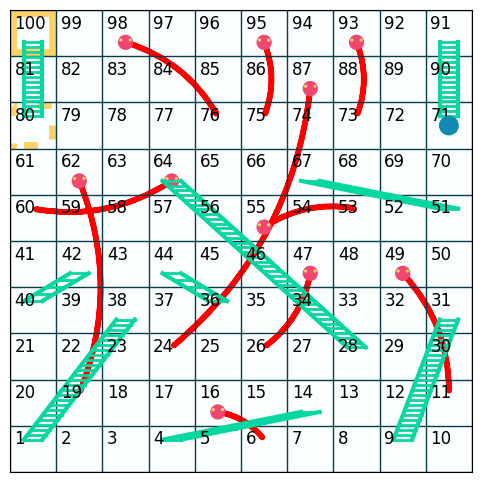

In [10]:
%matplotlib
from verimon.draw import animate_player_movement
import math
from IPython.display import HTML

# player_path = [(0, [])]
poss = product.simulate_paynt_assignment(assignment, 100000)
player_path = poss

goal_squares = [int(str(state.valuations)[5:-1]) 
                for state in product.mc.states 
                if "good" in state.labels]

animation = animate_player_movement(int(math.sqrt(n)), snakes, ladders, goal_squares, player_path)
HTML(animation.to_jshtml())